<a href="https://colab.research.google.com/github/m42tk7246v-png/JCU_MA3832_Stephenson/blob/main/Dive_ch2_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In reading *Dive Into Deep Learning*, I want to play and around and test the concepts. This is a workbook where I am do that. It is not a finished product but a sandbox to play in. Some code cells lead to runtime errors--these are left in as counterexamples.

This sandbox is also where I take notes.

As I go through I ask myself questions in *italics* and then find the answers one place or another.

 Once I am happy with the answer I have found, I copy or paste it in, editing or further annotating them myself. This kind of active note taking takes time but I find it has enormous payoff in retention of information.


# 2.1 Data Manipulation



In [8]:
import torch


In [9]:
x = torch.arange(12, dtype=torch.float32)
x.dtype

torch.float32

*What are all of the dtypes and the default?*

The default dtype is torch.int64.

All of the dtypes are as follows:

| dtype | Description |
|---|---|
| `torch.float32` / `torch.float` | 32-bit floating point (default for most ops) |
| `torch.float64` / `torch.double` | 64-bit floating point |
| `torch.float16` / `torch.half` | 16-bit floating point |
| `torch.bfloat16` | Brain floating point (16-bit, wider range than float16) |
| `torch.int8` | 8-bit signed integer |
| `torch.int16` / `torch.short` | 16-bit signed integer |
| `torch.int32` / `torch.int` | 32-bit signed integer |
| `torch.int64` / `torch.long` | 64-bit signed integer (default for integer ops) |
| `torch.uint8` | 8-bit unsigned integer |
| `torch.bool` | Boolean |
| `torch.complex64` | Complex number with float32 real and imaginary parts |
| `torch.complex128` | Complex number with float64 real and imaginary parts |

*What is a brain float point?*

A brain floating point (`bfloat16`) is a 16-bit format developed by Google Brain. It has the same number of exponent bits as `float32` (8 bits), but truncates the mantissa (significand) to just 7 bits instead of 23.

The key tradeoff compared to standard `float16`:

| | `float16` | `bfloat16` | `float32` |
|---|---|---|---|
| Exponent bits | 5 | 8 | 8 |
| Mantissa bits | 10 | 7 | 23 |
| Range | $\pm 65504$ | $\pm 3.4 \times 10^{38}$ | $\pm 3.4 \times 10^{38}$ |
| Precision | higher | lower | highest |

The practical upshot: `bfloat16` has the same numerical range as `float32`, so you can often drop `float32` weights down to `bfloat16` without overflow. `float16` is more precise but overflows much more easily during training, requiring extra care (loss scaling etc.).

`bfloat16` is common in modern deep learning hardware (TPUs, recent NVIDIA GPUs) where memory bandwidth matters more than precision.

The exponent of $10^{38}$ comes from $\log_{10}(2^{2^7}) \approx 38$.

*When is it safe to use an integer dtype?*

It's safe to use an integer dtype when your computation involves **no division, no gradients, and no continuous mathematics** — essentially when you're indexing or counting rather than calculating.

Common safe uses:

| Use case | Typical dtype |
|---|---|
| Class labels / targets in classification | `torch.int64` |
| Indices into an embedding table | `torch.int64` |
| Counting / binning | `torch.int32` / `int64` |
| Boolean masks | `torch.bool` |
| Pixel values (raw, before normalisation) | `torch.uint8` |

The main pitfall is that **integer tensors don't support gradients** — PyTorch will raise an error if you try to backpropagate through them. So anything in your forward pass that needs to be learned or differentiated must be floating point.

Given that using gradients (derivatives) will be a major theme for the course, we probably won't have many occassions to use integer dtypes, or if we do we will need to cast them as `float32` before feeding them into the network.






*When to use float32 versus float64?*

### float32 vs float64 in PyTorch

#### Default: always use float32

PyTorch defaults to `float32` (single precision) and you should too in almost
all deep learning contexts. GPUs are optimised for 32-bit arithmetic — on most
hardware, float64 operations run at a fraction of the speed of float32, and
consume twice the memory.

#### When to use float32
- Neural network weights, activations, and gradients
- Training and inference on GPU
- Any standard deep learning pipeline
- When memory or speed matters (i.e. almost always)

#### When to use float64
- Scientific computing or numerical methods where precision is critical
- Reproducing results from physics or statistics literature that assumes
  double precision
- When your input data is float64 and you need to match it exactly
- CPU-only work where speed is not a concern

#### The practical rule

If you are doing deep learning: **float32**.  
If you are doing numerical computation (ODE solvers, statistical modelling,
anything where small floating-point errors accumulate dangerously): **float64**.

#### Create with explicit dtype
torch.tensor(data, dtype=torch.float32)
torch.tensor(data, dtype=torch.float64)

#### Change dtype of existing tensor

tensor.float()    # → float32

tensor.double()   # → float64

#### Actually, better to use use .to()

x = torch.tensor([1.0, 2.0, 3.0])

x = x.to(torch.float64)

x = x.to(torch.int32)


#### Set global default
torch.set_default_dtype(torch.float64)

#### A note on float16 and bfloat16

Modern training often goes further and uses **float16** or **bfloat16**
(half precision) via mixed-precision training, halving memory again and
speeding up training on compatible GPUs. float32 sits in the middle —
more precise than float16, faster than float64.

In [10]:
x.numel()

12

In [11]:
x.shape # note there is no shape method, only the attribute

torch.Size([12])

In [12]:
X = x.reshape(3,4)
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [13]:
X.numel()

12

In [14]:
X.shape

torch.Size([3, 4])

We can initialise tensors to all zeros or ones as follows:

In [15]:
torch.zeros(2,3,4,5)

tensor([[[[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]]],


        [[[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]]]])

In [16]:
torch.ones((2,3,4,1))

tensor([[[[1.],
          [1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.],
          [1.]]],


        [[[1.],
          [1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.],
          [1.]]]])

We can also initialise a tensor drawn from the standard normal distribution:

In [17]:
torch.randn(3,4)

tensor([[ 0.5142, -0.2363,  1.0295,  1.7858],
        [ 0.3995,  0.2833, -0.1588, -0.6273],
        [ 1.1935, -0.7275, -0.5946, -0.6267]])

*How to initialise from other distributions?*

#### Standard normal — mean 0, std 1 (what we just used)
torch.randn(3, 4)

#### Uniform — values between 0 and 1
torch.rand(3, 4)

#### Uniform — values between a and b
torch.zeros(3, 4).uniform_(2.0, 5.0)

#### Normal with custom mean and std
torch.zeros(3, 4).normal_(mean=5.0, std=2.0)

#### Integers — uniform between low and high (exclusive)
torch.randint(low=0, high=10, size=(3, 4))

#### Bernoulli — each element is 1 with probability p
torch.bernoulli(torch.full((3, 4), 0.7))

#### Zeros, ones, or a constant
torch.zeros(3, 4)
torch.ones(3, 4)
torch.full((3, 4), fill_value=3.14)

In [18]:
# An example of a sample initialisation, before any computation.
# The underscore of normal_ means the values are updated in place and no
# new version of x is made. This is efficient for memory use
x = torch.zeros(3,4)
x.normal_(mean=10, std=2)

# However we don't want to use in place methods once a tensor is part of
# a computation
x = torch.randn(3, 4)
y = x * 2          # now x is in the computational graph
x.add_(1)          # dangerous — corrupts the graph

# More on this topic later

tensor([[ 0.9419,  0.8150, -1.4200,  1.4088],
        [ 0.6906,  0.2552,  1.3614, -0.4689],
        [ 0.4832,  1.6890,  1.9701,  2.3652]])

## 2.1.2 Indexing and Slicing



Recall the Python convention that x[a:b] starts at a and stops at b-1

In [19]:
x = [5,6,7,8,9,10]
x[1:3]

[6, 7]

Likewise for tensor slicing

In [20]:
X = torch.arange(60, dtype=torch.float32).reshape(3,4,5)
X

tensor([[[ 0.,  1.,  2.,  3.,  4.],
         [ 5.,  6.,  7.,  8.,  9.],
         [10., 11., 12., 13., 14.],
         [15., 16., 17., 18., 19.]],

        [[20., 21., 22., 23., 24.],
         [25., 26., 27., 28., 29.],
         [30., 31., 32., 33., 34.],
         [35., 36., 37., 38., 39.]],

        [[40., 41., 42., 43., 44.],
         [45., 46., 47., 48., 49.],
         [50., 51., 52., 53., 54.],
         [55., 56., 57., 58., 59.]]])

In [21]:
X[-1] # with just one value it is applied to dimension 0

tensor([[40., 41., 42., 43., 44.],
        [45., 46., 47., 48., 49.],
        [50., 51., 52., 53., 54.],
        [55., 56., 57., 58., 59.]])

In [22]:
X[1][-1]

tensor([35., 36., 37., 38., 39.])

In [23]:
X[0:2][-1]

tensor([[20., 21., 22., 23., 24.],
        [25., 26., 27., 28., 29.],
        [30., 31., 32., 33., 34.],
        [35., 36., 37., 38., 39.]])

In [24]:
X[1][0,2]

tensor(22.)

Note this is a tensor object. *How to make it just a number object?*

In [25]:
X[1][0,2].item()

22.0

In [26]:
# but
print(X[1][0,2:4])
X[1][0,2:4].item()

tensor([22., 23.])


RuntimeError: a Tensor with 2 elements cannot be converted to Scalar

*How does this compare to pull in tidyverse?*

## Extracting values from tensors: PyTorch vs R/tidyverse

### `.item()` — extract a single scalar

```python
X[1][0,2].item()   # returns 22.0 as a plain Python float
```

This only works on single-element tensors. The closest R equivalent is
indexing into a pulled column to get one value:

```r
df %>% pull(bill_length_mm) %>% .[[1]]   # returns 39.1 as a plain number
```

### The fuller analogy

**Single scalar:**
```python
X[0, 0].item()       # → 22.0  (plain Python float)
```
```r
df %>% pull(bill_length_mm) %>% .[[1]]   # → 39.1  (plain R number)
```

**Whole column as a list/vector:**
```python
X[:, 0].tolist()     # → [22.0, 31.0, 14.0]  (plain Python list)
```
```r
df %>% pull(bill_length_mm)   # → c(39.1, 39.5, 40.3, ...)  (plain R vector)
```

**Whole column as an array:**
```python
X[:, 0].numpy()      # → array([22., 31., 14.])  (NumPy array)
```
```r
df %>% pull(bill_length_mm) %>% as.numeric()   # → numeric vector
```

### Key point

`.item()` is for a **single value** only — PyTorch raises an error if
the tensor has more than one element. For multiple values, use
`.tolist()` (Python list) or `.numpy()` (NumPy array).

In [52]:
X[:, 0].numpy()

array([[ 0.,  1.,  2.,  3.,  4.],
       [20., 21., 22., 23., 24.],
       [40., 41., 42., 43., 44.]], dtype=float32)

In [53]:
# also
X.numpy()

array([[[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.]],

       [[20., 21., 22., 23., 24.],
        [25., 26., 27., 28., 29.],
        [30., 31., 32., 33., 34.],
        [35., 36., 37., 38., 39.]],

       [[40., 41., 42., 43., 44.],
        [45., 46., 47., 48., 49.],
        [50., 51., 52., 53., 54.],
        [55., 56., 57., 58., 59.]]], dtype=float32)

In other words, an array in NumPy can be more than 2D. The ease of
conversion between NumPy arrays and PyTorch tensors is a deliberate
design choice — both represent the same concept (an n-dimensional block
of numbers) and PyTorch was designed to interoperate smoothly with the
existing NumPy ecosystem.


## 2.1.3 Operations

In [54]:
X.exp()

tensor([[[1.0000e+00, 2.7183e+00, 7.3891e+00, 2.0086e+01, 5.4598e+01],
         [1.4841e+02, 4.0343e+02, 1.0966e+03, 2.9810e+03, 8.1031e+03],
         [2.2026e+04, 5.9874e+04, 1.6275e+05, 4.4241e+05, 1.2026e+06],
         [3.2690e+06, 8.8861e+06, 2.4155e+07, 6.5660e+07, 1.7848e+08]],

        [[4.8517e+08, 1.3188e+09, 3.5849e+09, 9.7448e+09, 2.6489e+10],
         [7.2005e+10, 1.9573e+11, 5.3205e+11, 1.4463e+12, 3.9313e+12],
         [1.0686e+13, 2.9049e+13, 7.8963e+13, 2.1464e+14, 5.8346e+14],
         [1.5860e+15, 4.3112e+15, 1.1719e+16, 3.1856e+16, 8.6593e+16]],

        [[2.3539e+17, 6.3984e+17, 1.7393e+18, 4.7278e+18, 1.2852e+19],
         [3.4934e+19, 9.4961e+19, 2.5813e+20, 7.0167e+20, 1.9073e+21],
         [5.1847e+21, 1.4093e+22, 3.8310e+22, 1.0414e+23, 2.8308e+23],
         [7.6948e+23, 2.0917e+24, 5.6857e+24, 1.5455e+25, 4.2012e+25]]])

In [55]:
X.dtype

torch.float32

In [56]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2,2,2,2])
y.dtype

torch.int64

So indeed the default is not float32 if you give it input that looks like Python integers. Hence the 1.0 entry in definition of x.


In [57]:
z = x + y
z.dtype

torch.float32

But sure enough x is recast as float to make this addition work. Another test:

In [58]:
a = torch.tensor([1,2,3,4], dtype = torch.float32)
b = torch.tensor([2,2,2,2], dtype = torch.float64)
c = a + b
c.dtype

torch.float64

In [59]:
x + y, x - y, x / y, x * y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 2.,  4.,  8., 16.]))

*What about pi?*



In [60]:
# Create a float32 scalar tensor of pi
pi_tensor = torch.tensor(torch.pi, dtype=torch.float32)
print(pi_tensor)

# Use it in math operations (e.g., converting degrees to radians)
degrees = torch.tensor([180.0, 90.0, 45.0])
radians = degrees * (torch.pi / 180.0)
print(radians)

tensor(3.1416)
tensor([3.1416, 1.5708, 0.7854])


In [61]:
x, y, x == y

(tensor([1., 2., 4., 8.]),
 tensor([2, 2, 2, 2]),
 tensor([False,  True, False, False]))

As usual we have to be careful with equality:

In [62]:
# Use PyTorch's native math functions
1.0 == torch.log(torch.exp(torch.tensor(217.0))) / 217.0

tensor(False)

but ...


In [63]:
# The bulletproof way to check if two float tensors are practically equal
lhs = torch.log(torch.exp(torch.tensor(17.0))) / 17.0
rhs = torch.tensor(1.0)

torch.allclose(lhs, rhs)  # Returns True

True

## 2.1.4 Broadcasting

That is, doing the best to perform tensor operations even when the dimensions are not the same, "broadcasting" over rows/columns/etc. This is analogous to R, but even more permissive. For example:

In [64]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

but ...

In [65]:
a + b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

## 2.1.5 Saving Memory

We don't want to constantly be reallocating memory, but often wish to perform calculations in place. An example of reallocation:

In [66]:
Y = torch.zeros([3,4,5]).uniform_(2,3)
Y

tensor([[[2.0022, 2.3437, 2.5793, 2.6973, 2.1916],
         [2.7672, 2.8348, 2.6255, 2.7148, 2.0061],
         [2.3692, 2.4871, 2.4731, 2.8478, 2.9902],
         [2.6427, 2.6720, 2.3160, 2.1760, 2.8105]],

        [[2.1997, 2.9497, 2.2875, 2.4850, 2.3545],
         [2.4245, 2.4825, 2.1278, 2.2881, 2.3539],
         [2.1796, 2.9589, 2.0168, 2.9546, 2.4242],
         [2.0014, 2.2829, 2.2827, 2.2296, 2.8036]],

        [[2.9462, 2.2124, 2.2199, 2.5489, 2.2395],
         [2.8421, 2.7958, 2.4372, 2.8942, 2.2937],
         [2.7834, 2.8495, 2.8942, 2.9286, 2.2807],
         [2.9992, 2.4687, 2.3866, 2.3756, 2.4150]]])

In [ ]:
X

In [67]:
before = id(Y)
Y = Y + X
if id(Y) != before:
  print("New memory has been allocated to Y")

New memory has been allocated to Y


It is possible to perform operations in place by using the slice operator:

In [ ]:
Z = torch.zeros([3,4,5])
print('id(Z):', id(Z))
Z[:] = X + Y
print('id(Z):', id(Z))

Another example:


In [68]:
before = id(X)
X += Y
id(X) == before

True

In [69]:
before = id(X)
X.add_(Y)  # This modifies X in place, exactly like X += Y
id(X) == before

True

## 2.1.6 Conversion to other Python Objects



In [70]:
A = X.numpy()
B = torch.from_numpy(A)
type(A), type(B), A.shape, B.shape

(numpy.ndarray, torch.Tensor, (3, 4, 5), torch.Size([3, 4, 5]))

Also, as we saw above we item:

In [71]:
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

## 2.1.8 Exercises

In [72]:
X, Y, X == Y

(tensor([[[  4.0043,   7.6875,  11.1587,  14.3946,  16.3833],
          [ 20.5345,  23.6696,  26.2510,  29.4297,  31.0122],
          [ 34.7383,  37.9742,  40.9462,  44.6957,  47.9804],
          [ 50.2855,  53.3440,  55.6321,  58.3521,  62.6210]],
 
         [[ 64.3994,  68.8993,  70.5751,  73.9700,  76.7090],
          [ 79.8489,  82.9650,  85.2556,  88.5761,  91.7078],
          [ 94.3592,  98.9179, 100.0336, 104.9092, 106.8484],
          [109.0028, 112.5659, 115.5654, 118.4592, 122.6072]],
 
         [[125.8924, 127.4249, 130.4399, 134.0977, 136.4790],
          [140.6842, 143.5917, 145.8743, 149.7884, 151.5874],
          [155.5667, 158.6991, 161.7884, 164.8573, 166.5613],
          [170.9984, 172.9374, 175.7731, 178.7512, 181.8300]]]),
 tensor([[[ 2.0022,  3.3437,  4.5793,  5.6973,  6.1916],
          [ 7.7672,  8.8348,  9.6255, 10.7148, 11.0061],
          [12.3692, 13.4871, 14.4731, 15.8478, 16.9902],
          [17.6427, 18.6720, 19.3160, 20.1760, 21.8105]],
 
         [[22.19

In [73]:
X/2 < Y, X > Y

(tensor([[[False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False]],
 
         [[False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False]],
 
         [[False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False],
          [False, False, False, False, False]]]),
 tensor([[[True, True, True, True, True],
          [True, True, True, True, True],
          [True, True, True, True, True],
          [True, True, True, True, True]],
 
         [[True, True, True, True, True],
          [True, True, True, True, True],
          [True, True, True, True, True],
          [True, True, True, True, True]],
 
         [[True, True, True, True, True],
          [True, True, True, True, True],
 

In [74]:
Z = X.reshape([2,30])
Z


tensor([[  4.0043,   7.6875,  11.1587,  14.3946,  16.3833,  20.5345,  23.6696,
          26.2510,  29.4297,  31.0122,  34.7383,  37.9742,  40.9462,  44.6957,
          47.9804,  50.2855,  53.3440,  55.6321,  58.3521,  62.6210,  64.3994,
          68.8993,  70.5751,  73.9700,  76.7090,  79.8489,  82.9650,  85.2556,
          88.5761,  91.7078],
        [ 94.3592,  98.9179, 100.0336, 104.9092, 106.8484, 109.0028, 112.5659,
         115.5654, 118.4592, 122.6072, 125.8924, 127.4249, 130.4399, 134.0977,
         136.4790, 140.6842, 143.5917, 145.8743, 149.7884, 151.5874, 155.5667,
         158.6991, 161.7884, 164.8573, 166.5613, 170.9984, 172.9374, 175.7731,
         178.7512, 181.8300]])

In [75]:
Z + X

RuntimeError: The size of tensor a (30) must match the size of tensor b (5) at non-singleton dimension 2

In [76]:
Z = X.reshape([6,2,5])
Z

tensor([[[  4.0043,   7.6875,  11.1587,  14.3946,  16.3833],
         [ 20.5345,  23.6696,  26.2510,  29.4297,  31.0122]],

        [[ 34.7383,  37.9742,  40.9462,  44.6957,  47.9804],
         [ 50.2855,  53.3440,  55.6321,  58.3521,  62.6210]],

        [[ 64.3994,  68.8993,  70.5751,  73.9700,  76.7090],
         [ 79.8489,  82.9650,  85.2556,  88.5761,  91.7078]],

        [[ 94.3592,  98.9179, 100.0336, 104.9092, 106.8484],
         [109.0028, 112.5659, 115.5654, 118.4592, 122.6072]],

        [[125.8924, 127.4249, 130.4399, 134.0977, 136.4790],
         [140.6842, 143.5917, 145.8743, 149.7884, 151.5874]],

        [[155.5667, 158.6991, 161.7884, 164.8573, 166.5613],
         [170.9984, 172.9374, 175.7731, 178.7512, 181.8300]]])

In [77]:
X + Z

RuntimeError: The size of tensor a (4) must match the size of tensor b (2) at non-singleton dimension 1

Moral of the example above: there are limits to broadcasting. The PyTorch library won't force a binary operation between tensors when the dimensions don't match somewhere logical. This is reassuring.

In [78]:
a = torch.arange(60).reshape(3, 4, 5)
b = torch.arange(5)

# Display both tensors
a, b

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([0, 1, 2, 3, 4]))

In [79]:
a + b

tensor([[[ 0,  2,  4,  6,  8],
         [ 5,  7,  9, 11, 13],
         [10, 12, 14, 16, 18],
         [15, 17, 19, 21, 23]],

        [[20, 22, 24, 26, 28],
         [25, 27, 29, 31, 33],
         [30, 32, 34, 36, 38],
         [35, 37, 39, 41, 43]],

        [[40, 42, 44, 46, 48],
         [45, 47, 49, 51, 53],
         [50, 52, 54, 56, 58],
         [55, 57, 59, 61, 63]]])

Moral of the story: this works if the last dimensions match

In [80]:
a = torch.arange(60).reshape(3, 4, 5)

b = torch.arange(3).reshape(3,1)

a,b

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([[0],
         [1],
         [2]]))

In [81]:
a + b

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 1

# 2.2 Data Preprocessing



In [82]:
import os

# os.makedirs creates a directory; exist_ok=True means no error if it already exists
# os.path.join builds a file path correctly for any OS (Windows/Mac/Linux)
os.makedirs(os.path.join('..', 'data'), exist_ok=True)

# Construct the full path to the CSV file: ../data/house_tiny.csv
data_file = os.path.join('..', 'data', 'house_tiny.csv')

# Open the file for writing ('w' mode), then write a small CSV dataset
with open(data_file, 'w') as f:
    f.write('''NumRooms,RoofType,Price
NA,NA,127500
2,NA,106000
4,Slate,178100
NA,NA,140000''')

data_file  # Displays the file path as the cell output

'../data/house_tiny.csv'

In [83]:
import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms RoofType   Price
0       NaN      NaN  127500
1       2.0      NaN  106000
2       4.0    Slate  178100
3       NaN      NaN  140000


*What arguments can `pd.read_csv` take?*

There are many — here are the most useful ones grouped by purpose:

**File & encoding**
| Argument | Description |
|---|---|
| `filepath_or_buffer` | Path, URL, or file object |
| `sep` / `delimiter` | Delimiter character (default `,`) |
| `encoding` | e.g. `'utf-8'`, `'latin-1'` |
| `compression` | `'gzip'`, `'zip'`, `'bz2'`, etc. |

**Columns & rows**
| Argument | Description |
|---|---|
| `header` | Row number to use as column names (default `0`) |
| `names` | Provide your own column names |
| `index_col` | Column(s) to use as the row index |
| `usecols` | Only load a subset of columns |
| `skiprows` | Rows to skip at the top |
| `nrows` | Only read this many rows |
| `skipfooter` | Rows to skip at the bottom |

**Missing values**
| Argument | Description |
|---|---|
| `na_values` | Extra strings to treat as NaN (e.g. `'NA'`, `'--'`) |
| `keep_default_na` | Whether to use pandas' built-in NaN strings |
| `na_filter` | Set `False` to disable NaN detection entirely |

**Data types**
| Argument | Description |
|---|---|
| `dtype` | Dict mapping column names to types |
| `parse_dates` | Columns to parse as datetime |

**Performance**
| Argument | Description |
|---|---|
| `chunksize` | Return an iterator of DataFrames of this size |
| `low_memory` | Process in chunks to reduce memory (default `True`) |


In [84]:
# Look again at the imported data
print(data)



   NumRooms RoofType   Price
0       NaN      NaN  127500
1       2.0      NaN  106000
2       4.0    Slate  178100
3       NaN      NaN  140000


A few things to notice:

1. **The row index** (0, 1, 2, 3) was added automatically by pandas — it wasn't in the CSV.

2. **`NumRooms` is `float64`**, not integer — because pandas can't store `NaN` in an integer column, so it promotes to float. That's why we see `2.0` and `4.0` instead of `2` and `4`.

3. **`RoofType` is object (string)** — `NaN` here is a genuine missing string value, and `Slate` is the only real category.

4. **`Price` is `int64`** — no missing values, so it stays as a clean integer.

The `NA` strings in your CSV were correctly recognised as `NaN` because pandas treats `'NA'` as a missing value by default (`keep_default_na=True`).


Now to reference the data, we want to use **iloc**, integer-based location indexing. In R this is the default. In pandas, it requires calling `data.iloc[]`.

What to do with the missing values? First of all, we can turn NaN into a category.

`get_dummies` converts a categorical column into multiple binary (0/1) columns — one per category. This is called **one-hot encoding**.

Our `RoofType` column has two distinct values: `Slate` and `NaN`. After `get_dummies`, those become two columns:

| RoofType_Slate | RoofType_nan |
|---|---|
| 0 | 1 |
| 0 | 1 |
| 1 | 0 |
| 0 | 1 |

Each row gets a `1` in exactly one column, and `0` elsewhere.

**Why do this?** Machine learning models (and PyTorch tensors) require purely numeric input. A string column like `RoofType` can't be fed into a model directly — one-hot encoding turns it into numbers without implying any false ordering (e.g. you don't want the model to think `Slate = 2 > NA = 1`).

`dummy_na=True` means missing values (`NaN`) get their own column rather than being silently dropped, which lets the model learn from the fact that data is missing.

____

*The equivalent in R?*

Hmm, in base R:

```
model.matrix(~ RoofType - 1, data = inputs)
```

or in the tidyverse adjacent tidymodels ecosystem via `recipes`, we have

```
library(recipes)
recipe(~ RoofType, data = inputs) |>
  step_dummy(RoofType, one_hot = TRUE) |>
  prep() |>
  bake(new_data = NULL)
```


In [85]:
# Split the DataFrame into inputs (first two columns) and targets (third column)
# iloc[:, 0:2] — all rows, columns 0 and 1 (NumRooms, RoofType)
# iloc[:, 2]   — all rows, column 2 (Price)
inputs, targets = data.iloc[:, 0:2], data.iloc[:, 2]

# One-hot encode categorical columns (RoofType becomes RoofType_Slate, RoofType_nan etc.)
# dummy_na=True — NaN values get their own indicator column instead of being ignored
# Numeric columns (NumRooms) are left unchanged
inputs = pd.get_dummies(inputs, dummy_na=True)

print(inputs)

   NumRooms  RoofType_Slate  RoofType_nan
0       NaN           False          True
1       2.0           False          True
2       4.0            True         False
3       NaN           False          True


For missing numerical values a common heuristic is to replace the missing values with the mean:




In [86]:
inputs = inputs.fillna(inputs.mean())
print(inputs)

   NumRooms  RoofType_Slate  RoofType_nan
0       3.0           False          True
1       2.0           False          True
2       4.0            True         False
3       3.0           False          True


Ok, where are we. We have preprocessed our inputs and we still have targets:


In [87]:
print(inputs,"\n")
print(targets)

   NumRooms  RoofType_Slate  RoofType_nan
0       3.0           False          True
1       2.0           False          True
2       4.0            True         False
3       3.0           False          True 

0    127500
1    106000
2    178100
3    140000
Name: Price, dtype: int64


Now we can load these into tensors:

In [88]:
# pandas has no direct tensor converter — we must go via numpy as an intermediate step
# .to_numpy(dtype=float) also casts bool columns (True/False) to 1.0/0.0
X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(targets.to_numpy(dtype=float))
X, y

(tensor([[3., 0., 1.],
         [2., 0., 1.],
         [4., 1., 0.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

Actually, this code from the book is a bit careless with data types. Better to convert the data type to float32, for the reasons discussed above. So ...

In [89]:
X = torch.tensor(inputs.to_numpy(dtype='float32'))
y = torch.tensor(targets.to_numpy(dtype='float32'))
X, y, X.dtype, Y.dtype

(tensor([[3., 0., 1.],
         [2., 0., 1.],
         [4., 1., 0.],
         [3., 0., 1.]]),
 tensor([127500., 106000., 178100., 140000.]),
 torch.float32,
 torch.float32)

## 2.3 Linear Algebra


Scalars, as we have already seen above:


In [90]:
x = torch.tensor(3.0)
y = torch.tensor(2.0)
pi = torch.tensor(torch.pi)
x, y, pi, x.dtype, y.dtype, pi.dtype

(tensor(3.),
 tensor(2.),
 tensor(3.1416),
 torch.float32,
 torch.float32,
 torch.float32)

In [91]:
torch.sin(x/y*pi), x + y, x**y

(tensor(-1.), tensor(5.), tensor(9.))

## 2.3.2 Vectors

Note the following example:

In [92]:
x = torch.arange(3)
x, x[2], x[2].item(), len(x), x.shape, x.shape[0] == len(x)

(tensor([0, 1, 2]), tensor(2), 2, 3, torch.Size([3]), True)

but ...


In [93]:
x.shape.item()

AttributeError: 'torch.Size' object has no attribute 'item'

## 2.3.3 Matrices

Matrices and their transposes, e.g.,

In [94]:
A = torch.arange(6).reshape(3, 2)
A, A.T, A.shape, A.T.shape

(tensor([[0, 1],
         [2, 3],
         [4, 5]]),
 tensor([[0, 2, 4],
         [1, 3, 5]]),
 torch.Size([3, 2]),
 torch.Size([2, 3]))

A symmetric matrix:


In [95]:
A = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
A == A.T, (A == A.T).all(), (A == A.T).all().item()

(tensor([[True, True, True],
         [True, True, True],
         [True, True, True]]),
 tensor(True),
 True)

and not ...


In [96]:
A[1,0] = 1
A == A.T, (A == A.T).all(), (A == A.T).all().item()

(tensor([[ True, False,  True],
         [False,  True,  True],
         [ True,  True,  True]]),
 tensor(False),
 False)

## 2.3.5 Basic Properties of Tensor Arithmetic



In [97]:
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone()  # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

In [98]:
# Hadamard, entry-wise product

A*B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

In [100]:
# Scalar multiplication

a = 2
X = torch.arange(24).reshape(2, 3, 4)
X, a + X, (a * X).shape

(tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 13, 14, 15],
          [16, 17, 18, 19],
          [20, 21, 22, 23]]]),
 tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

## 2.3.6 Reduction



In [99]:
x = torch.arange(3, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2.]), tensor(3.))

In [101]:
A, A.shape, A.sum()

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 torch.Size([2, 3]),
 tensor(15.))

In [ ]:
A.sum(axis=0), A.sum(axis=1)

but note that ...


In [102]:
A.sum(axis=0).shape, A.sum(axis=1).shape

(torch.Size([3]), torch.Size([2]))

... hence this is not like "projection"; I would expect natively that adding down the columns gives us a row vector and adding across the rows gives us a column vector. Not so. (See 2.3.7 Non-Reduction Sum below.)

We can also add across multiple dimensions:


In [103]:
A.sum(axis=[0, 1]) == A.sum()  # Same as A.sum()

tensor(True)

or more more richly

In [36]:
X, X.shape

(tensor([[[ 0.,  1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.,  9.],
          [10., 11., 12., 13., 14.],
          [15., 16., 17., 18., 19.]],
 
         [[20., 21., 22., 23., 24.],
          [25., 26., 27., 28., 29.],
          [30., 31., 32., 33., 34.],
          [35., 36., 37., 38., 39.]],
 
         [[40., 41., 42., 43., 44.],
          [45., 46., 47., 48., 49.],
          [50., 51., 52., 53., 54.],
          [55., 56., 57., 58., 59.]]]),
 torch.Size([3, 4, 5]))

In [104]:
X.sum(axis=[0,1]), X.sum(axis=[0,2]), X.sum(axis=[1,2])

(tensor([60, 66, 72, 78]), tensor([ 60,  92, 124]), tensor([ 66, 210]))

Also ..

In [105]:
A, A.mean(), A.sum() / A.numel()

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor(2.5000),
 tensor(2.5000))

In [106]:
A.mean(axis=0), A.sum(axis=0) / A.shape[0]

(tensor([1.5000, 2.5000, 3.5000]), tensor([1.5000, 2.5000, 3.5000]))

## 2.3.7 Non-Reduction Sum

Aha! Now we do behave in the manner I expected

In [107]:
A

tensor([[0., 1., 2.],
        [3., 4., 5.]])

In [108]:
sum_A = A.sum(axis=1, keepdims=True)
sum_A, sum_A.shape

(tensor([[ 3.],
         [12.]]),
 torch.Size([2, 1]))

In [109]:
X, X.shape

(tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 13, 14, 15],
          [16, 17, 18, 19],
          [20, 21, 22, 23]]]),
 torch.Size([2, 3, 4]))

In [110]:
sum_X = X.sum(axis = 1, keepdims=True)
sum_X, sum_X.shape

(tensor([[[12, 15, 18, 21]],
 
         [[48, 51, 54, 57]]]),
 torch.Size([2, 1, 4]))

This is nice because using broadcasting we can use this idea to normalise a dimension to sum to 1. For instance:

In [111]:
A, A / sum_A

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[0.0000, 0.3333, 0.6667],
         [0.2500, 0.3333, 0.4167]]))

In [112]:
# In this example the sum of down the columns of each submatrix sum to 1.

X, X / sum_X

(tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 13, 14, 15],
          [16, 17, 18, 19],
          [20, 21, 22, 23]]]),
 tensor([[[0.0000, 0.0667, 0.1111, 0.1429],
          [0.3333, 0.3333, 0.3333, 0.3333],
          [0.6667, 0.6000, 0.5556, 0.5238]],
 
         [[0.2500, 0.2549, 0.2593, 0.2632],
          [0.3333, 0.3333, 0.3333, 0.3333],
          [0.4167, 0.4118, 0.4074, 0.4035]]]))

We can also calculate the cumulative sum of elements:

In [113]:
A, A.cumsum(axis=0), A.cumsum(axis=1)

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[0., 1., 2.],
         [3., 5., 7.]]),
 tensor([[ 0.,  1.,  3.],
         [ 3.,  7., 12.]]))

In [114]:
X, X.cumsum(axis=0), X.cumsum(axis=1), X.cumsum(axis=2)

(tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 13, 14, 15],
          [16, 17, 18, 19],
          [20, 21, 22, 23]]]),
 tensor([[[ 0,  1,  2,  3],
          [ 4,  5,  6,  7],
          [ 8,  9, 10, 11]],
 
         [[12, 14, 16, 18],
          [20, 22, 24, 26],
          [28, 30, 32, 34]]]),
 tensor([[[ 0,  1,  2,  3],
          [ 4,  6,  8, 10],
          [12, 15, 18, 21]],
 
         [[12, 13, 14, 15],
          [28, 30, 32, 34],
          [48, 51, 54, 57]]]),
 tensor([[[ 0,  1,  3,  6],
          [ 4,  9, 15, 22],
          [ 8, 17, 27, 38]],
 
         [[12, 25, 39, 54],
          [16, 33, 51, 70],
          [20, 41, 63, 86]]]))

## 2.3.8 Dot Products



In [115]:
y = torch.ones(3, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2.]), tensor([1., 1., 1.]), tensor(3.))

Or element wise (aka Hadamard) multiplication and then summing:

In [116]:
torch.sum(x * y), torch.sum(x * y).item()

(tensor(3.), 3.0)

## 2.3.9 Matrix-Vector Multiplication



In [117]:
A, x

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([0., 1., 2.]))

In [118]:
# mv for matrix-vector
A.shape, x.shape, torch.mv(A, x), A@x

(torch.Size([2, 3]), torch.Size([3]), tensor([ 5., 14.]), tensor([ 5., 14.]))

NB The result has the data type of a row vector, not a 1x2 matrix

## 2.3.10 Matrix-Matrix Multiplication



In [119]:
# mm for matrix-matrix
B = torch.ones(3,4)
torch.mm(A, B), A@B

(tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]))

## 2.3.11 Norms

The default `norm` method calculates the $\ell^2$ norm:

In [120]:
u = torch.tensor([3.0, -4])
torch.norm(u)

tensor(5.)

For the $\ell^1$ norm:

In [121]:
torch.abs(u).sum()

tensor(7.)

The Frobenius norm on a matrix is also calculated using `norm`:


In [44]:
torch.norm(torch.ones((4, 9)))

tensor(6.)

Recall: The spectral norm of a matrix is its **largest singular value**.

Recall that for a matrix **A**, the singular value decomposition (SVD) gives:

**A = UΣVᵀ**

where Σ is a diagonal matrix of singular values σ₁ ≥ σ₂ ≥ ... ≥ 0. The spectral norm is σ₁ — the largest one.


Intuitively, the maximum amount $A$ can stretch a vector:

$$\|A\|_2 = \max_{\|x\|=1} \|Ax\|$$

It is implemented as:

In [45]:
n1 = torch.linalg.matrix_norm(A, ord=2)   # or equivalently:
n2 = torch.linalg.svdvals(A)[0]           # largest singular value

n1, n2

NameError: name 'A' is not defined

Note that `len` corresponds to length of axis 0:

In [122]:
## Sandbox
A = torch.ones(2,3,4)
A, len(A), A.numel()

(tensor([[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],
 
         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]),
 2,
 24)

In [123]:
import numpy as np
torch.linalg.norm(A) == np.sqrt(A.numel())

tensor(True)

Question 10

In [124]:
import torch
import tracemalloc

A = torch.randn(2**5,  2**8)
B = torch.randn(2**8,  2**12)
C = torch.randn(2**12, 2**7)

tracemalloc.start()
AB_C = (A @ B) @ C
_, peak1 = tracemalloc.get_traced_memory(); tracemalloc.reset_peak()

A_BC = A @ (B @ C)
_, peak2 = tracemalloc.get_traced_memory(); tracemalloc.stop()

print(f"(AB)C  peak memory: {peak1 / 1024:.1f} KB")
print(f"A(BC)  peak memory: {peak2 / 1024:.1f} KB")
print(f"Results match: {torch.allclose(AB_C, A_BC)}")

(AB)C  peak memory: 19.1 KB
A(BC)  peak memory: 19.2 KB
Results match: False


Insight: A(BC) wins because the intermediate BC has shape (2^8, 2^7) vs (AB) which has shape (2^5, 2^12) — but more importantly at the real scales, (AB) intermediate would be astronomically larger.

Moral of the story: multiply along the longest axis first

Question 11

In [125]:
A = torch.randn(2**5, 2**8)
B = torch.randn(2**8, 2**12)

# C is a fresh transpose — contiguous copy, different memory layout to B
C_copy = B.T.contiguous()

import time

reps = 100
t0 = time.perf_counter()
for _ in range(reps): A @ B
t1 = time.perf_counter()
for _ in range(reps): A @ C_copy.T   # C_copy.T restores original layout
t2 = time.perf_counter()

print(f"AB:    {(t1-t0)/reps*1000:.3f} ms")
print(f"AC^T:  {(t2-t1)/reps*1000:.3f} ms")

# Now set C = B.T WITHOUT cloning — C shares B's storage, just with swapped strides
C_view = B.T    # no copy, non-contiguous
print(f"\nC_view shares storage with B: {C_view.data_ptr() == B.data_ptr()}")
# AC^T is now just AB again under the hood — same data, same result, no extra memory
print(f"A @ C_view.T matches A @ B: {torch.allclose(A @ C_view.T, A @ B)}")

## Version 2
print("\n VERSION 2 \n")

reps = 100
t0 = time.perf_counter()
for _ in range(reps): A @ B
t1 = time.perf_counter()
for _ in range(reps): A @ B.T.contiguous().T   # force a contiguous copy each time
t2 = time.perf_counter()

print(f"AB:                        {(t1-t0)/reps*1000:.3f} ms")
print(f"AB with forced contiguous: {(t2-t1)/reps*1000:.3f} ms")

AB:    1.458 ms
AC^T:  1.526 ms

C_view shares storage with B: True
A @ C_view.T matches A @ B: True

 VERSION 2 

AB:                        1.485 ms
AB with forced contiguous: 3.844 ms


Hmm, *What is the moral of the story of question 11 after all?*

In modern PyTorch, **don't worry about transposing before a matmul** — the BLAS backend handles it for free.

The one case where memory layout *does* matter is if you find yourself calling `.contiguous()` explicitly to fix a non-contiguous tensor before some other operation. That copy has real cost and is worth avoiding by thinking about your layout upstream.

The more practically useful lesson from Q11 is the **shared storage** result: `C = B.T` costs nothing — no copy, no extra memory — because it's just a view with swapped strides. That's the habit worth building: prefer views over copies wherever possible.

*But why call `.contiguous()`?*

It's complicated. Maybe return to this later.

Question 12

In [126]:
A = torch.randn(100, 200)
B = torch.randn(100, 200)
C = torch.randn(100, 200)

# Stack along a new first axis → shape (3, 100, 200)
ABC = torch.stack([A, B, C])
print(f"Stacked shape: {ABC.shape}")   # torch.Size([3, 100, 200])

# Recover B by indexing coordinate 1 of axis 0
B_recovered = ABC[1]
print(f"Recovered shape: {B_recovered.shape}")   # torch.Size([100, 200])
print(f"Matches original B: {torch.allclose(B_recovered, B)}")

Stacked shape: torch.Size([3, 100, 200])
Recovered shape: torch.Size([100, 200])
Matches original B: True


# 2.4 Calculus



In [127]:
!pip install --no-deps d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.7 MB/s eta 0:00:00


The next cell sets up the standard environment used throughout the *Dive into Deep Learning* (d2l) textbook.

**`%matplotlib inline`**

This is a Jupyter magic command — it tells the notebook to render matplotlib plots directly inside the notebook output cells, rather than opening a separate window. It must be called before any plotting.

**`import numpy as np`**

Imports NumPy, the foundational array library for numerical computing in Python. Even though we are primarily using PyTorch, NumPy is still needed as a bridge — for example when converting tensors for plotting with matplotlib, which expects NumPy arrays.

**`from matplotlib_inline import backend_inline`**

`matplotlib_inline` is the package that implements the `%matplotlib inline` behaviour in modern Jupyter. Importing `backend_inline` directly gives access to configuration options such as `backend_inline.set_matplotlib_formats('svg')` for higher-resolution plots.

**`from d2l import torch as d2l`**

Imports the d2l convenience library, specifically its PyTorch edition. The d2l package bundles helper functions used repeatedly throughout the textbook — things like plotting learning curves, loading standard datasets, and defining common training loops — so that the notebooks can focus on the concepts rather than boilerplate code. Importing it `as d2l` means all those utilities are accessed via the `d2l` namespace (e.g. `d2l.plot()`, `d2l.train_ch3()`).

In [128]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

The limiting proceedure of the derivative illustrated:

In [129]:
def f(x):
    return 3 * x ** 2 - 4 * x

for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


Decoding the textbook, we learn that all of the functions given in this section are now loaded for us and can be found in `d2l`. Thus:


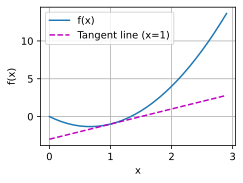

In [130]:
x = np.arange(0, 3, 0.1)
d2l.plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

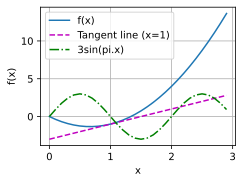

In [131]:
x = np.arange(0, 3, 0.1)
d2l.plot(x, [f(x), 2 * x - 3, 3*np.sin(np.pi*x)], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)', '3sin(pi.x)'])

Ok. This isn't terrible. Will be useful for us.

## 2.4.3 Gradient and friends

Usefully and importantly:

For $x \in \mathbf{R}^n$

$${\large \nabla} \| x \|^{\!2}_{\!2} = 2x$$

and similarly, for $X \in \mathbf{R}^{n \times m}$,

$${\large \nabla} \| X \|^{\!2}_{F} = 2 X$$


# 2.5 Automatic Differentiation



In [132]:
import torch

In [133]:
x = torch.arange(4.0)
x, x.dtype

(tensor([0., 1., 2., 3.]), torch.float32)

We now ensure that x has a gradient attribute, which will be populated
automatically as calculations are performed on it. The advantage of
attaching this to the tensor itself is that it removes the burden from
the programmer of manually tracking and managing the derivative
calculations — PyTorch handles this bookkeeping for us behind the scenes.

In [134]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
print(x.grad)  # The gradient is None by default

None


In [135]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

### What `grad_fn=<MulBackward0>` means

`y` is not a plain number — it is a tensor that **knows how it was created**.
Specifically it knows the last operation that produced it was a multiplication
(`Mul`), and it has stored enough information to compute the derivative of that
operation when needed.

This is the computational graph in action. Because `x` was created with
`requires_grad=True`, PyTorch silently tracked every operation performed on it.
The `grad_fn` is the record of that tracking — a pointer back through the chain
of operations. The `Backward0` suffix indicates this is the function that will
be called when PyTorch is asked to compute gradients.

### The contrast

If `x` had been created without `requires_grad=True`, the output would just be:

```python
tensor(28.)
```
No `grad_fn` — just a plain number with no history attached.

### Summary

The `28.` is the value. The `grad_fn=<MulBackward0>` is PyTorch's bookkeeping
receipt saying: *"I remember how I got here, and I can work backwards through
the computation if you ask me to."*

Let us now do so. We know that $y = 2x^Tx$ and thus $\nabla y = 4x$. To get `torch` to now calculate this for us, we run these two lines:


In [136]:
# y.backward() tells PyTorch to work backwards through the computational
# graph that was built when we calculated y = 2 * torch.dot(x, x).
# It computes the gradient of y with respect to every tensor that has
# requires_grad=True — in this case, x.
y.backward()

# x.grad now contains ∇y, the gradient of y with respect to the vector x.
# Since y = 2 * xᵀx, the gradient is ∇y = 4x.
# For x = [0, 1, 2, 3], this gives 4x = [0, 4, 8, 12],
# which is exactly what PyTorch returns.
x.grad

tensor([ 0.,  4.,  8., 12.])

Now what will seem strange about this to students new to neural networks is why are we storing the information about the derivative with x instead of y. It will turn out that this is much more convenient for our purposes.

How is it convenient for our purposes? Well, the answer to that question will have to wait but trust us, it's a good choice and hopefully you will see for yourself why it is a good choice soon.

Let's look at a richer example.

Suppose $u = u(x,y)$, $y = f(z)$, and $Q = g(u(x,y),f(z))$.



In [137]:


# Define the input variables — these are our parameters, so requires_grad=True
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = torch.tensor(4.0, requires_grad=True)

# u = u(x, y) — some function of x and y
u = x**2 + y**3          # u(2, 3) = 4 + 27 = 31

# v = f(z) — some function of z alone
v = torch.sin(z)          # f(4) = sin(4) ≈ -0.7568

# Q = g(u(x,y), f(z)) — a function of both u and v
Q = u * v                 # g(u, v) = u * v

# Ask PyTorch to compute the gradients of Q with respect to x, y, and z
Q.backward()

print(f"u = {u.item():.4f}")
print(f"v = {v.item():.4f}")
print(f"Q = {Q.item():.4f}")
print()
print(f"∂Q/∂x = {x.grad.item():.4f}")   # = 2x * sin(z)
print(f"∂Q/∂y = {y.grad.item():.4f}")   # = 3y² * sin(z)
print(f"∂Q/∂z = {z.grad.item():.4f}")   # = u * cos(z)

u = 31.0000
v = -0.7568
Q = -23.4609

∂Q/∂x = -3.0272
∂Q/∂y = -20.4337
∂Q/∂z = -20.2630


The chain rule tells us analytically:

$$\frac{\partial Q}{\partial x} = 2x \cdot \sin(z), \qquad \frac{\partial Q}{\partial y} = 3y^2 \cdot \sin(z), \qquad \frac{\partial Q}{\partial z} = (x^2 + y^3)\cos(z)$$

PyTorch computes all three automatically via the computational graph —
we can verify the outputs match these formulas:

In [138]:
results = [
    (2*x*torch.sin(z)).item(),
    (3*y**2*torch.sin(z)).item(),
    ((x**2 + y**3)*torch.cos(z)).item()
]
[round(r, 4) for r in results]

[-3.0272, -20.4337, -20.263]

*Do we also have the partial derivatives with respect to $u$ and $v$?*:

In [139]:
print(f"∂Q/∂u = {u.grad.item():.4f}")
print(f"∂Q/∂v = {v.grad.item():.4f}")

/tmp/ipykernel_32842/1029971321.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  print(f"∂Q/∂u = {u.grad.item():.4f}")


AttributeError: 'NoneType' object has no attribute 'item'

Nope! PyTorch discards these intermediate calculations. If we want them, we have to call `.retain_grad()` on those variables before calling `backward()`:


In [140]:
u = x**2 + y**3
v = torch.sin(z)
Q = u * v

# Must be called before backward()
u.retain_grad()
v.retain_grad()

Q.backward()

print(f"∂Q/∂u = {u.grad.item():.4f}")   # now works
print(f"∂Q/∂v = {v.grad.item():.4f}")   # now works

∂Q/∂u = -0.7568
∂Q/∂v = 31.0000


To quote Claude: "The practical takeaway: in neural network training you never need gradients at intermediate nodes — you only need them at the weights (leaf tensors) to update them. So PyTorch's default behaviour of only storing leaf gradients is exactly right for the typical use case."

*The definition of a leaf tensor is...?*


## Leaf tensors

A **leaf tensor** is a tensor that was created directly by the user rather
than being the result of an operation on other tensors.

More precisely, PyTorch considers a tensor a leaf if:

- It was created explicitly (e.g. `torch.tensor(...)`, `torch.randn(...)`) —
  regardless of whether `requires_grad` is True or False
- It was not produced by any computation involving other tensors

We can check with:

```python
x.is_leaf   # True
u.is_leaf   # False — u was produced by x**2 + y**3
```

In neural network terms: the weight matrices and bias vectors are the
leaves — you created them, and they are what you want to update.
Everything else (activations, loss) is computed from them and sits higher
up the graph as intermediate nodes.

PyTorch only stores gradients automatically for leaf tensors. If you need
the gradient at an intermediate node, you must call `.retain_grad()` on it
before `.backward()`.

In [141]:
# True. And then False — u was produced by x**2 + y**3

x.is_leaf, u.is_leaf

(True, False)

## 2.5.2 Backward for Non-Scalar Variables

### Gradients of non-scalar tensors

So far, `y` has been a scalar — a single number — and `.backward()` worked
without any extra arguments. But what happens when `y` is a vector?

Mathematically, the gradient $\nabla_{\mathbf{x}} \mathbf{y}$ of a vector
with respect to a vector is no longer a vector — it is a **Jacobian matrix**:
an $m \times n$ matrix where entry $(i, j)$ is $\partial y_i / \partial x_j$.

PyTorch refuses to compute and store this full Jacobian by default, for two
reasons:

- It is expensive — for large tensors the Jacobian can be enormous
- In practice, what we almost always want in deep learning is not the full
  Jacobian but the **vector-Jacobian product** $\mathbf{v}^\top \nabla_{\mathbf{x}} \mathbf{y}$,
  which collapses everything back to a vector the same size as $\mathbf{x}$

So PyTorch requires you to supply the vector $\mathbf{v}$ explicitly via the
`gradient` argument. Passing `torch.ones(len(y))` as $\mathbf{v}$ is
equivalent to summing all elements of `y` first and then taking the gradient
— which is the most common case.

In [143]:
# Initialise x as a vector of floats with requires_grad=True so that
# PyTorch tracks all operations performed on it
x = torch.randn(4, requires_grad=True)

# PyTorch accumulates (adds) gradients into x.grad every time .backward()
# is called, rather than overwriting the previous value. That is,
# after each call to .backward():
#
#   x.grad ← x.grad + ∇_x y
#
# This is a deliberate design choice: in some architectures (e.g. RNNs)
# you genuinely want to sum gradients across multiple forward passes.
#
# However in the standard training loop, accumulation is almost always
# a bug. Consider what happens without zeroing:
#
#   Iteration 1: x.grad = 2x              (correct)
#   Iteration 2: x.grad = 2x + 2x = 4x   (wrong — doubled)
#   Iteration 3: x.grad = 2x + 4x = 6x   (wrong — tripled)
#
# The gradient update x ← x - α∇_x y would use the wrong gradient,
# and training would diverge or behave erratically.
#
# So before each new backward pass we zero out the accumulated gradient.
# Note the trailing underscore — this is an in-place operation, consistent
# with PyTorch's convention that methods ending in _ modify the tensor
# directly rather than returning a new one.
#
# In a full neural network training loop, the optimizer handles this for you:
#
#   optimizer.zero_grad()   # zeros all parameter gradients at once
#   loss.backward()         # accumulate fresh gradients
#   optimizer.step()        # update parameters using x.grad
#
# On first run x.grad is None, which we enforce:
if x.grad is not None:
    x.grad.zero_()

# y is now a vector, not a scalar — each element y_i = x_i²
y = x * x    # y = [x₀², x₁², x₂², x₃²]

# Because y is a vector, PyTorch cannot compute ∇_x y directly —
# that would require storing the full Jacobian J, where J_{ij} = ∂y_i/∂x_j.
#
# Instead PyTorch computes the vector-Jacobian product vᵀJ for a
# user-supplied vector v (passed via the gradient= argument).
#
# Here y_i = x_i² and y_i does not depend on x_j for i ≠ j, so J is diagonal:
#
#         ⎡ 2x₀  0    0    0  ⎤
#   J =   ⎢  0   2x₁  0    0  ⎥
#         ⎢  0    0   2x₂  0  ⎥
#         ⎣  0    0    0   2x₃ ⎦
#
# With v = [1, 1, 1, 1], the vector-Jacobian product is:
#
#   vᵀJ = [2x₀, 2x₁, 2x₂, 2x₃] = 2x
#
# which is stored in x.grad.
# Note: y.sum().backward() is equivalent and more concise.
y.backward(gradient=torch.ones(len(y)))

# x.grad now contains 2x — the elementwise derivative ∂y_i/∂x_i for each i
x, x.grad, torch.isclose(2*x, x.grad)

(tensor([ 2.3704,  0.1982, -0.0850, -1.6983], requires_grad=True),
 tensor([ 4.7407,  0.3965, -0.1700, -3.3965]),
 tensor([True, True, True, True]))

## 2.5.3 Detaching Computation


Some times we will want to perform a calculation on an intermediate variable outside the main computational graph. Here's an example:


In [144]:
# Define the input variables — these are our parameters, so requires_grad=True
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = torch.tensor(4.0, requires_grad=True)

# u = u(x, y) — some function of x and y
u = x**2 + y**3          # u(2, 3) = 4 + 27 = 31

# v = f(z) — some function of z alone
v = torch.sin(z)          # f(4) = sin(4) ≈ -0.7568

# Detach u from the computational graph — u_detached has the same numerical
# value as u but PyTorch has no memory of how it was created.
# Its provenance (x and y) is wiped out entirely.
u_detached = u.detach()

# Q = u_detached * v
# Because u_detached has no ancestors in the graph, when we differentiate Q
# PyTorch treats u_detached as a plain constant with respect to x and y.
# Gradients will NOT flow back through u_detached to x and y.
Q = u_detached * v

Q.backward()

print(f"u          = {u.item():.4f}")
print(f"v          = {v.item():.4f}")
print(f"Q          = {Q.item():.4f}")
print()

# x.grad and y.grad are None — gradients could not flow back through
# u_detached to reach x and y
print(f"x.grad = {x.grad}")   # None
print(f"y.grad = {y.grad}")   # None

# z.grad is still populated — v = sin(z) was NOT detached, so the
# gradient flows back through v to z normally
print(f"∂Q/∂z  = {z.grad.item():.4f}")   # = u_detached * cos(z)

u          = 31.0000
v          = -0.7568
Q          = -23.4609

x.grad = None
y.grad = None
∂Q/∂z  = -20.2630


## 2.5.4 Gradients and Python Control Flow

Even if our final root variable, the end point of calculations, has gone through a complicated series of control statements, the gradient with respect to the leaf tensors is still defined. For example:


In [145]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [146]:
# initialise a as a scalar
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

## Now note that as b is always a scalar multiple of a, its gradient is simply
## scalar multiple:

a, d, a.grad, a.grad == d / a, torch.isclose(a.grad, d/a)

(tensor(1.7116, requires_grad=True),
 tensor(1752.6969, grad_fn=<MulBackward0>),
 tensor(1024.),
 tensor(True),
 tensor(True))

## 2.5.6 Exercises

## 2.5.6 Question 2

What happens if you call backward twice?


In [148]:
x = torch.randn(10).requires_grad_(True)
print(x.requires_grad)   # True

y = x**2 + torch.sin(torch.pi * x)

# First backward pass
y.backward(gradient=torch.ones(len(y)))
print("After first backward:")
print(x.grad)

# Second backward pass — no zero_() in between
# Gradients will ACCUMULATE, i.e. x.grad = x.grad + ∇y
# so x.grad will be exactly double what it was after the first pass
y.backward(gradient=torch.ones(len(y)))
print("\nAfter second backward (no zeroing):")
print(x.grad)

# Confirm: second result is exactly twice the first
# ∂y/∂x = 2x + π*cos(πx), so accumulated grad = 2 * (2x + π*cos(πx))

True
After first backward:
tensor([-4.9098,  0.8958, -1.1263, -0.3409,  1.3495, -1.0463,  2.4032, -0.3637,
        -4.7963, -5.0379])


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

It doesn't like it because the graph is junked after one traversal. Why? Because values are usually updated so it efficient to get rid of the old graph now. If we **do** want to traverse it twice, we need to say retain the graph.

In [149]:
x = torch.randn(10).requires_grad_(True)
print(x.requires_grad)   # True

y = x**2 + torch.sin(torch.pi * x)

# First backward pass — retain_graph=True tells PyTorch to keep the
# computational graph in memory after this backward pass.
# By default PyTorch frees the graph after .backward() to save memory,
# which is why the second call fails without this flag.
y.backward(gradient=torch.ones(len(y)), retain_graph=True)
print("After first backward:")
print(x.grad)

# Second backward pass — gradients accumulate into x.grad
# x.grad = x.grad + ∇y, so the result is exactly double the first pass
y.backward(gradient=torch.ones(len(y)))
print("\nAfter second backward (no zeroing):")
print(x.grad)

True
After first backward:
tensor([ 3.1939, -3.2515, -1.2306,  1.8307,  2.3648, -2.1016,  2.4978,  2.8817,
        -2.5059,  0.0623])

After second backward (no zeroing):
tensor([ 6.3877, -6.5029, -2.4612,  3.6614,  4.7297, -4.2033,  4.9957,  5.7635,
        -5.0118,  0.1245])


## 2.5.6 Question 8.

When/why do we use backward versus forward differentiation?

### Forward vs Backward Differentiation

#### Forward mode differentiation

Computes derivatives alongside the forward pass, propagating a "tangent"
vector through the computation. For a function $f: \mathbb{R}^n \rightarrow \mathbb{R}^m$:

- Requires **one forward pass per input dimension** — cost scales with $n$
- Intermediate storage is minimal — no need to remember the whole graph
- Naturally parallelisable across input dimensions
- Best when $n \ll m$ — few inputs, many outputs

#### Backward mode differentiation (what PyTorch uses)

Runs the forward pass first, stores intermediate values, then propagates
gradients backwards. For the same $f$:

- Requires **one backward pass per output dimension** — cost scales with $m$
- Requires storing the entire computational graph in memory during the forward pass
- Best when $m \ll n$ — many inputs, few outputs

#### Why deep learning uses backward mode

In neural networks you typically have:

- $n$ = millions of parameters (inputs to the loss)
- $m$ = 1 (the scalar loss)

So $m \ll n$ by an enormous margin. One backward pass gives you all million
gradients simultaneously. Forward mode would require one pass per parameter —
completely intractable.

#### When forward mode wins

- $n$ is small and $m$ is large — e.g. computing a full Jacobian of a
  low-dimensional input
- Memory is severely constrained — forward mode needs no graph storage
- Real-time applications where you cannot afford to store the graph
- Computing Jacobian-vector products efficiently

#### Summary

| | Forward mode | Backward mode |
|---|---|---|
| Cost scales with | $n$ (inputs) | $m$ (outputs) |
| Memory | Low | High (stores graph) |
| Best for | $n \ll m$ | $m \ll n$ |
| Deep learning | Rarely | Always |

So wait a minute, let's clarify what is and what is not junked after one call to `backward()`

### What gets freed after `.backward()`

After one call to `.backward()`, what gets freed is the **cached intermediate
values** — the specific numbers computed and stored at each node during that
particular forward pass. For example, the cached value of `torch.sin(z)` at
that specific value of `z`, which was needed to evaluate `cos(z)` during the
backward pass via the chain rule.

What is **not** freed is the **graph structure** — the topology recording which
operations connect which variables. But this is somewhat moot, because the
graph structure is not really a separate stored object anyway. It is implicit
in your Python code. `y = x**2 + torch.sin(z)` always has the same structure;
PyTorch rebuilds it fresh on the next forward pass by executing your code again
with new values.

The mental model:

| | Lives in | Freed after `.backward()`? |
|---|---|---|
| Graph structure | Your code | Never — rebuilt each forward pass |
| Cached intermediate values | GPU/CPU memory | Yes — freed immediately |
| Gradients (`.grad`) | Leaf tensors | No — persist until `zero_grad()` |

## 2.5.6 Question 4

Let $f(x) = \sin x$. Plot the graph of $f$ and $f'$ using automatic differentiation.


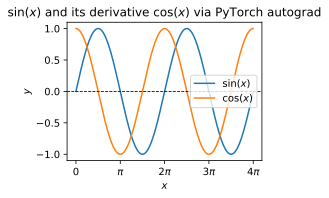

In [150]:
# Version 1

import numpy as np, torch as torch

domain = [0, 4*np.pi]
L = domain[1] - domain[0]
steps = 1000
x_values = []
y_values = []
y_dash_values = []

for i in range(steps):
  x = torch.tensor(domain[0] + i/steps * L).requires_grad_(True)
  y = torch.sin(x)
  y.backward()
  x_values.append(x.item())
  y_values.append(y.item())
  y_dash_values.append(x.grad.item())

import matplotlib.pyplot as plt

plt.plot(x_values, y_values, label=r'$\sin(x)$')
plt.plot(x_values, y_dash_values, label=r'$\cos(x)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'$\sin(x)$ and its derivative $\cos(x)$ via PyTorch autograd')
plt.legend()
plt.xticks(
    [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi],
    ['0', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$']
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()



Hmm, ok it works. Can we just make a tensor with all of the x values all at once instead, same as `seq` in R?

Yes. First, we have

### `torch.linspace`

```python
torch.linspace(start, end, steps, *, out=None, dtype=None,
               layout=torch.strided, device=None, requires_grad=False)
```

Creates a 1D tensor of `steps` evenly spaced values from `start` to `end`
**inclusive**.

#### Key arguments

| Argument | Description |
|---|---|
| `start` | Starting value |
| `end` | Ending value (inclusive) |
| `steps` | Number of points |
| `dtype` | Data type (default `float32`) |
| `device` | `'cpu'` or `'cuda'` |
| `requires_grad` | Whether to track gradients |

#### Examples

```python
torch.linspace(0, 1, 5)
# tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

torch.linspace(0, 4*np.pi, 1000)
# tensor of 1000 points from 0 to 4π inclusive

torch.linspace(0, 10, 3)
# tensor([0., 5., 10.])
```

#### Contrast with `torch.arange`

```python
torch.arange(start, end, step)    # end is EXCLUSIVE, step is the spacing
torch.linspace(start, end, steps) # end is INCLUSIVE, steps is the count
```

The R equivalent is `seq(from, to, length.out = steps)` — same idea, same
inclusive behaviour.

### KEY IDEA: VECTORISATION

Ok, being able to specify all of the values of $x$ is a minor technical move to what we do next.

In version 1, we have $1000$ values of $x$ equispaced on the interval $[0, 4\pi]$. Suppose now we have $1000$ variables $x_j$ with their particular values being the those equispaced values, let's call the values $a_j$. In other words, $x_1 = a_1, x_2 = a_2$, etc.

Let now $x$ be the vector of $x_j$ and define the function

$$S(x) = \sum_{j = 1}^{1000} \sin(x_j)$$

Then $$\frac{\partial S}{\partial x_j} (a_j) = \sin'(a_j) = \cos(a_j)$$

This is what we implement in version 2 below:

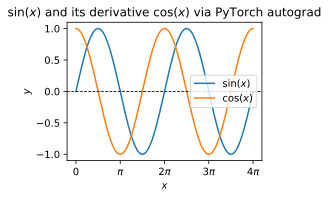

In [151]:
# Version 2

import numpy as np
import torch
import matplotlib.pyplot as plt

x = torch.linspace(0, 4*np.pi, 1000, requires_grad=True)
y = torch.sin(x)

# y is a vector of 1000 values — one sin(x_i) for each x_i.
# .backward() requires a scalar output, so we must reduce y first.
# y.sum() collapses the 1000 values to a single number:
#
#   S = Σ sin(x_j)  for j = 1, ..., 1000
#
# Since each y_j = sin(x_j) depends only on x_j and not on any other x_k,
# the gradient of S with respect to x_i is simply:
#
#   ∂S/∂x_j = cos(x_j)
#
# which is exactly what we want. This is equivalent to:
#
#   y.backward(gradient=torch.ones(len(y)))
#
# but more concise we have:

y.sum().backward()

# Ok, we have all the data. Now we plot. To pass the data to plot
# we need it to be a plain tensor, which matplotlib is happy to plot.
# So at a minimum we need to call .detach() on x and y so they don't have the
# requires_grad attribute. Note that we do not need to call it on x.grad because
# it never had that attribute.
#
# To make this even cleaner, we also convert to NumPy array with an additional call
# to .numpy()
#
# By the way, it would NOT work to just write for instance x.numpy()
# PyTorch has the opinion that if we want to step outside the computational
# graph then we need to be explicit about it--calling .detach() is such
# a statement of intent.

# The `r` prefix before the strings here makes them raw strings--it tells
# Python to treat backslashes as literal characters rathan than escape sequences
# which would cause problems. (For example \n new line, \t tab, \b backspace)

plt.plot(x.detach().numpy(), y.detach().numpy(), label=r'$\sin(x)$')
plt.plot(x.detach().numpy(), x.grad, label=r'$\cos(x)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'$\sin(x)$ and its derivative $\cos(x)$ via PyTorch autograd')
plt.legend()
plt.xticks(
    [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi],
    ['0', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$']
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()

This is an example of a fundamental technique in scientific computing, called **vectorisation**. Vectorisation goes back decades. In general, it can be orders of magnitude faster than using `for` loops.

Ok, now **Version 3**. I didn't use plotting from `d2l`. Let's do that now.


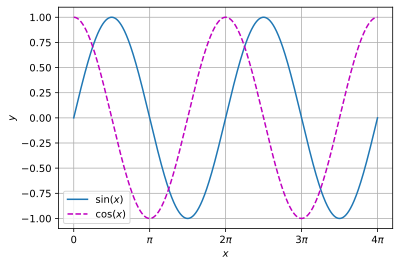

In [152]:

import numpy as np
import torch
import matplotlib.pyplot as plt

x = torch.linspace(0, 4*np.pi, 1000, requires_grad=True)
y = torch.sin(x)

y.sum().backward()

x_np = x.detach().numpy()

d2l.plot(
    x_np,
    [y.detach().numpy(), x.grad.numpy()],
    xlabel=r'$x$',
    ylabel=r'$y$',
    legend=[r'$\sin(x)$', r'$\cos(x)$'],
    figsize=(6, 4)
)


# Now the truth is d2l.plot is not so awesome. How for instance can one
# imitate the x axis from above? After the fact one has to add this code:

# Add π-labelled x ticks after the d2l.plot call
plt.xticks(
    [0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi],
    ['0', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$']
)
plt.show()

# This works because d2l.plot is using matplotlib under the hood, so any
# standard plt. call can be made immediately after and it will apply
# to the same figure.
#
# So why not just use matplotlib and avoid the dependency? Indeed.

# 2.6 Probability and Statistics

I imagine we have covered most of this already, or it will be sufficiently familiar that I am not going to make many notes. Let's see!


In [153]:
!pip install --no-deps d2l

In [154]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

`Multinomial` makes a tensor which has sampled a distribution. Documentation:

### `torch.distributions.multinomial.Multinomial`

```python
Multinomial(total_count, probs=None, logits=None)
```

Models the result of drawing `total_count` samples from a categorical
distribution with given class probabilities. Each sample is a vector of
counts — how many times each category was drawn.

#### Key arguments

| Argument | Description |
|---|---|
| `total_count` | Number of draws per sample (e.g. 1 for a single coin flip) |
| `probs` | Tensor of unnormalised probabilities — automatically normalised |
| `logits` | Alternative to `probs` in log-space |

#### Key methods

| Method | Description |
|---|---|
| `.sample((n,))` | Draw `n` samples, returns tensor of shape `(n, k)` |
| `.log_prob(x)` | Log probability of observing count vector `x` |

#### Examples

```python
# Fair coin — two outcomes with equal probability
fair_probs = torch.tensor([0.5, 0.5])

# Single flip (total_count=1), one sample
Multinomial(1, fair_probs).sample()
# tensor([1., 0.])  or  tensor([0., 1.])

# Single flip, 10000 samples — shape (10000, 2)
Multinomial(1, fair_probs).sample((10000,))

# Roll a fair die (6 outcomes), 5 rolls at once (total_count=5)
die_probs = torch.ones(6) / 6
Multinomial(5, die_probs).sample()
# e.g. tensor([1., 0., 2., 0., 1., 1.])  — counts summing to 5
```

### Note

When `total_count=1`, each sample is a **one-hot vector** — exactly one
entry is 1 and the rest are 0. This is the standard way to simulate a
single categorical draw (coin flip, die roll, etc.) in PyTorch.

In [155]:
# random.random() draws from Uniform[0,1]

num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [52, 48]


In [156]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([59., 41.])

Returning now a draw from a discrete r.v. with a given probability distribution. Note the probabilities given don't have to add to one; they are normalised by `Multinomial`.

In [157]:
probs = torch.tensor([0.2, 0.2, 0.4])
Multinomial(100, probs).sample()

tensor([23., 28., 49.])

<class 'torch.Tensor'>
torch.Size([10000, 2]) 20000


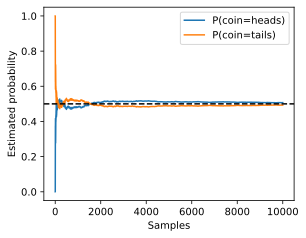

In [158]:
# Simulate 10000 coin flips. Each row is one flip — a one-hot vector
# of length 2, e.g. [1, 0] for heads or [0, 1] for tails.
# Shape: (10000, 2)
counts = Multinomial(1, fair_probs).sample((10000,))
print(type(counts))
print(counts.size(), counts.numel())

# Compute the cumulative sum along dim=0 (down the rows).
# cum_counts[i] contains the total number of heads and tails
# seen in the first i+1 flips.
# e.g. if counts = [[1,0],[0,1],[1,0],...] then
#      cum_counts = [[1,0],[1,1],[2,1],...]
# Shape: (10000, 2)
cum_counts = counts.cumsum(dim=0)

# At each row i, divide the cumulative counts by the total number of
# flips seen so far to get running probability estimates.
# cum_counts.sum(dim=1, keepdims=True) sums across columns (heads + tails)
# giving the total flips at each row — shape (10000, 1).
# keepdims=True keeps the column dimension so broadcasting works correctly
# when dividing the (10000, 2) matrix by the (10000, 1) column vector.
# estimates[i] = [heads so far / total so far, tails so far / total so far]
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

# Convert to NumPy array for matplotlib
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

Following on from the plots at the end of the previous section, 2.6, let's rewrite this using matplotlib instead. Hmm! How very similar they are. I say bye-bye to `d2l.plt` and its dependency. Matplotlib is likely to be with us for some time.


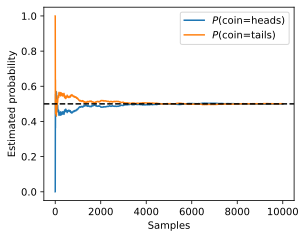

In [159]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

plt.figure(figsize=(4.5, 3.5))
plt.plot(estimates[:, 0], label=r'$P(\text{coin=heads})$')
plt.plot(estimates[:, 1], label=r'$P(\text{coin=tails})$')
plt.axhline(y=0.5, color='black', linestyle='dashed')
plt.xlabel('Samples')
plt.ylabel('Estimated probability')
plt.legend()
plt.show()

## 2.6.7 Discussion

### Alea iacta est, the die is cast

**Aleatoric uncertainty**, the uncertainty intrinsic to the problem due to the genuine randomness unaccounted for by the observed varaiables.

**Epistemic uncertainty**, the uncertainty over a model's parameters

## Chebyshev's Inequality

**Theorem.** Let $X$ be a random variable with well defined mean $\mu$ and variance $\sigma^2$.
Then for any $k > 1$:

$$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}$$

That is, the probability that $X$ deviates from its mean by at least $k$ standard
deviations is at most $1/k^2$, regardless of the shape of the distribution.

**Corollary.** Setting $k = \sqrt{2}$ gives $P(|X - \mu| \geq \sqrt{2}\sigma) \leq 1/2$,
so draws from any distribution lie within $\sqrt{2}$ standard deviations of the
mean with probability at least $1/2$.

# 2.7 Documentation
### 2.7.1 Functions and Classes in a Module

To know what functions and classes can be called in a module, use `dir`:


In [160]:
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'GeneralizedPareto', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'InverseGamma', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PositiveDefiniteTransform', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'T

## 2.7.2 Specific Functions and Classes

Examples:


In [161]:
help(d2l.plot)

Help on function plot in module d2l.torch:

plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None, ylim=None, xscale='linear', yscale='linear', fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None)
    Plot data points.

    Defined in :numref:`sec_calculus`



In [162]:
help(torch.linspace)

Help on built-in function linspace in module torch:

linspace(...)
    linspace(start, end, steps, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor

    Creates a one-dimensional tensor of size :attr:`steps` whose values are evenly
    spaced from :attr:`start` to :attr:`end`, inclusive. That is, the value are:

    .. math::
        (\text{start},
        \text{start} + \frac{\text{end} - \text{start}}{\text{steps} - 1},
        \ldots,
        \text{start} + (\text{steps} - 2) * \frac{\text{end} - \text{start}}{\text{steps} - 1},
        \text{end})


    From PyTorch 1.11 linspace requires the steps argument. Use steps=100 to restore the previous behavior.

    Args:
        start (float or Tensor): the starting value for the set of points. If `Tensor`, it must be 0-dimensional
        end (float or Tensor): the ending value for the set of points. If `Tensor`, it must be 0-dimensional
        steps (int): size of the constructed tensor

    

# END
